# Image Classification with CNN for Malaria Data

#### Malaria is a life-threatening disease caused by parasites transmitted through the bites of infected mosquitoes. Early and accurate diagnosis is crucial for effective treatment. In this project, we develop a Convolutional Neural Network (CNN)-based image classification model to detect malaria by analyzing cell images. The dataset consists of 27,558 microscopic images, categorized as Infected and Uninfected. The goal is to compare different models and determine the most effective approach for malaria detection.

### importing necessary libraries

In [4]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D

In [5]:
labels = ['Parasitized', 'Uninfected']  # Defining our labels
img_path = 'cell_images/'  # Specifying the directory containing the images

In [6]:
img_list = []  # List to store image paths
label_list = []  # List to store corresponding labels

In [7]:
for label in labels:  # Loop through each label in the labels list
    for img_file in os.listdir(img_path + label):  # Loop through all files in the label's folder
        img_list.append(img_path + label + '/' + img_file)  # Append the full image path to img_list
        label_list.append(label)  # Append the corresponding label to label_list

In [8]:
df = pd.DataFrame({'img': img_list, 'label': label_list})  # Create a DataFrame with image paths and labels

In [9]:
df.head()

,img,label
0,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized
1,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized
2,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized
3,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized
4,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized


In [10]:
df.tail()

,img,label
27555,cell_images/Uninfected/C99P60ThinF_IMG_2015091...,Uninfected
27556,cell_images/Uninfected/C99P60ThinF_IMG_2015091...,Uninfected
27557,cell_images/Uninfected/C99P60ThinF_IMG_2015091...,Uninfected
27558,cell_images/Uninfected/C99P60ThinF_IMG_2015091...,Uninfected
27559,cell_images/Uninfected/Thumbs.db,Uninfected


In [11]:
# Mapping labels to numerical values
d = {'Parasitized': 1, 'Uninfected': 0}  # Converting labels to numerical data
df['encode_label'] = df['label'].map(d)  # Adding a new column with encoded labels

In [12]:
df.head()

,img,label,encode_label
0,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized,1
1,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized,1
2,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized,1
3,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized,1
4,cell_images/Parasitized/C100P61ThinF_IMG_20150...,Parasitized,1


In [13]:
df = df[~df['img'].str.endswith('Thumbs.db')] 
df = df.reset_index(drop=True)  

### Exploratory Data Analysis (EDA)

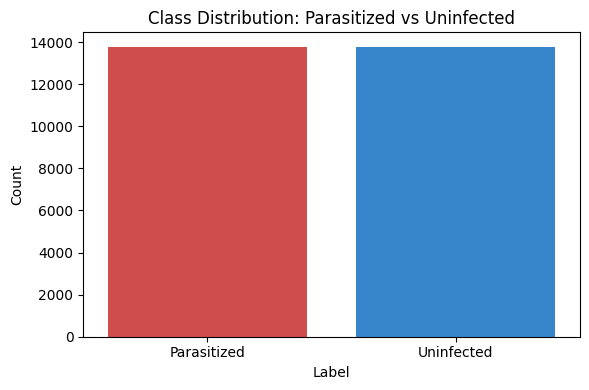

label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64


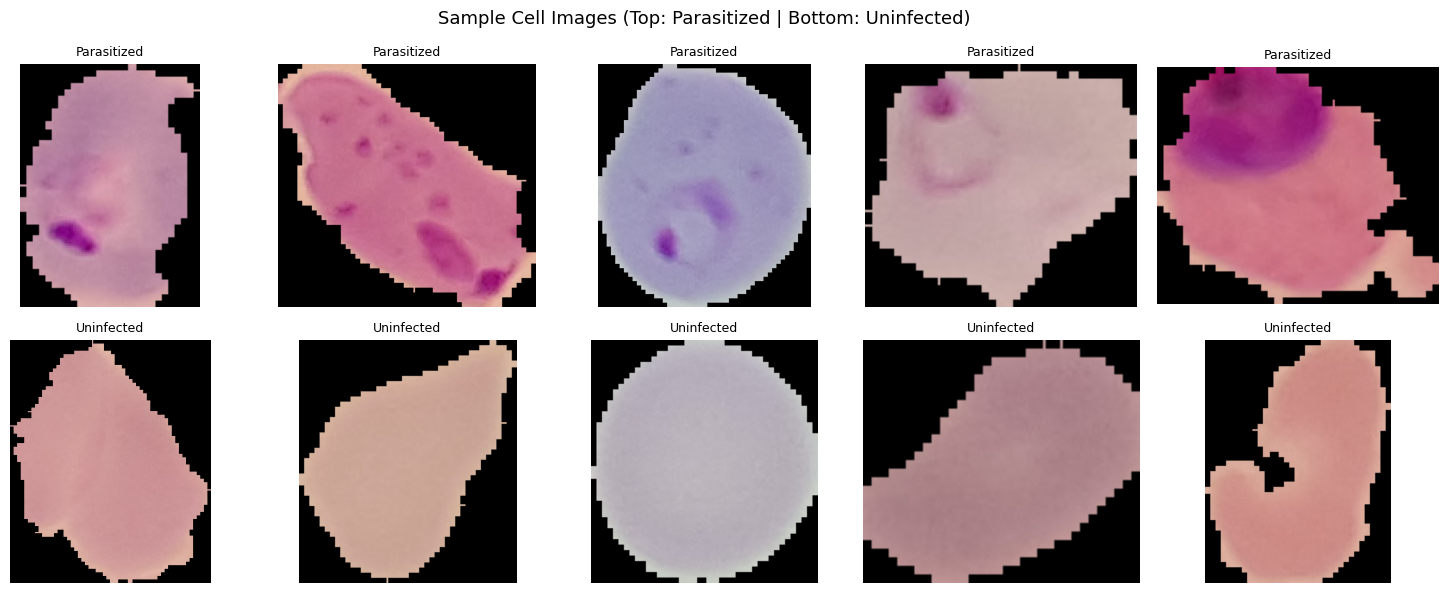

In [15]:
# --- 1. Class Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette={'Parasitized': '#E53935', 'Uninfected': '#1E88E5'})
plt.title('Class Distribution: Parasitized vs Uninfected')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(df['label'].value_counts())

# --- 2. Sample Cell Images ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Cell Images (Top: Parasitized | Bottom: Uninfected)', fontsize=13)

for row_idx, label in enumerate(['Parasitized', 'Uninfected']):
    samples = df[df['label'] == label].sample(5, random_state=42)
    for col_idx, (_, record) in enumerate(samples.iterrows()):
        img = cv2.imread(record['img'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].set_title(label, fontsize=9)
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

In [16]:
x = []
y = []

for img_path, label in zip(df['img'], df['label']):
    img = cv2.imread(str(img_path))

    if img is None:
        print(f"Skipping invalid image: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    img = cv2.resize(img, (30, 30))
    img = img / 255.0
    x.append(img)
    y.append(1 if label == 'Parasitized' else 0)

In [17]:
y = np.array(y)

In [18]:
x = np.array(x)

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [20]:
model = Sequential()
model.add(Input(shape=(30, 30, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(250, activation='relu'))
model.add(Dense(150, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [21]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15, verbose=1)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7051 - loss: 0.5409 - val_accuracy: 0.9407 - val_loss: 0.1679
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9416 - loss: 0.1724 - val_accuracy: 0.9443 - val_loss: 0.1598
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9546 - loss: 0.1344 - val_accuracy: 0.9552 - val_loss: 0.1372
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9578 - loss: 0.1231 - val_accuracy: 0.9497 - val_loss: 0.1523
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9604 - loss: 0.1111 - val_accuracy: 0.9508 - val_loss: 0.1454
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9635 - loss: 0.1025 - val_accuracy: 0.9499 - val_loss: 0.1583
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9695 - loss: 0.0912 - val_accuracy: 0.9479 - val_loss: 0.1566
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9734 - loss: 0.0777 - val_accurac

In [22]:
model.save('my_malaria_cnn_model.h5')

### Conclusion
##### This project successfully used CNN models to classify malaria-infected and uninfected blood cell images. The results show that deep learning can assist in automated malaria detection, improving diagnostic efficiency.